# Building a Quantitative Trading Strategy
## Part 2: Strategy Development

This notebook demonstrates how to develop a complete trading strategy using
the predictive model we built in Part 1. We'll cover entry/exit signals,
trade sizing, leverage, and risk management.

**Repository:** https://github.com/memlabs-research/build-a-quant-trading-strategy

## Trading System Overview

Recall our three-step pipeline:

```
signal = model(x)          # Step 1: Generate predictions (Part 1)
orders = strategy(signal)  # Step 2: Convert to trading orders (This Part)
execute(orders)            # Step 3: Execute trades (Part 3)
```

In Part 1, we built a model that predicts 12-hour ahead log returns.
This notebook focuses on **Step 2**: transforming predictions into actionable trades.

---
## Strategy Types

There are two main types of trading strategies:

### 1. Maker Strategies (Limit Orders)
- **Provide liquidity** to the market
- Place limit orders that add to the order book
- **Earn rebates** or tighter spreads
- Example: Placing a buy limit below market price

### 2. Taker Strategies (Market Orders)
- **Consume liquidity** from the market
- Execute immediately at best available price
- **Pay fees** (taker fee)
- Example: Market buy/sell orders

**This notebook focuses on Taker strategies** as they are simpler to implement
and analyze.

---
## Key Strategy Decisions

For a taker strategy, we need to answer three questions:

1. **Entry/Exit**: When do we open and close positions?
2. **Trade Sizing**: How much capital do we allocate per trade?
3. **Leverage**: Should we use borrowed capital? How much?

**Goal:** Maximize profits by leveraging our model's statistical edge.

---
## 1. Environment Setup

### 1.1 Import Libraries

In [8]:
# Core libraries
import polars as pl
import numpy as np
from datetime import datetime, timedelta
import random
import torch
import torch.nn as nn

# Quant Research Library
from src.quant_research import (
    # Data loading
    load_ohlc_timeseries_range,
    # Feature engineering
    add_log_return_features,
    # Model utilities
    timeseries_split,
    add_model_predictions,
    print_model_params,
    LinearModel,
    # Backtesting
    add_tx_fees,
    add_equity_curve,
    add_compounding_trades,
    # Visualization
    plot_static_timeseries,
    plot_column,
    plot_multiple_lines,
)

# Visualization
import altair as alt

# Exchange connector
from src.connectors.binance import MAKER_FEE, TAKER_FEE, download_date_range

---
## 2. Load Trained Model

We load the model trained in Part 1. The model has been updated:

- **Forecast horizon**: 12 hours (increased from 8 hours to reduce fee impact)
- **Features**: 3 lagged log returns (increased from 1 for better predictions)

The model weights are stored in `data/models/model_weights.pth`.

In [9]:

# Initialize model architecture (3 input features)
model = LinearModel(3)

# Load trained weights
# Note: weights_only=True is a security best practice
model.load_state_dict(torch.load('data/models/model_weights.pth', weights_only=True))

# Set to evaluation mode (disables dropout, batch norm training behavior)
model.eval()

LinearModel(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)

### 2.1 Inspect Model Parameters

In [10]:

print_model_params(model)

linear.weight:
[[-0.09520352 -0.03124688 -0.0465919 ]]
linear.bias:
[0.00107722]


---
## 3. Understanding Mean Reversion

Our model's negative weight on lag_1 suggests **mean reversion**:
when prices move up, they tend to reverse.

### Mean Reversion Intuition

$$\hat{r}_{t+1} \approx -0.10 \times r_t$$

If the market went up (+2%), we predict it will go down next period.

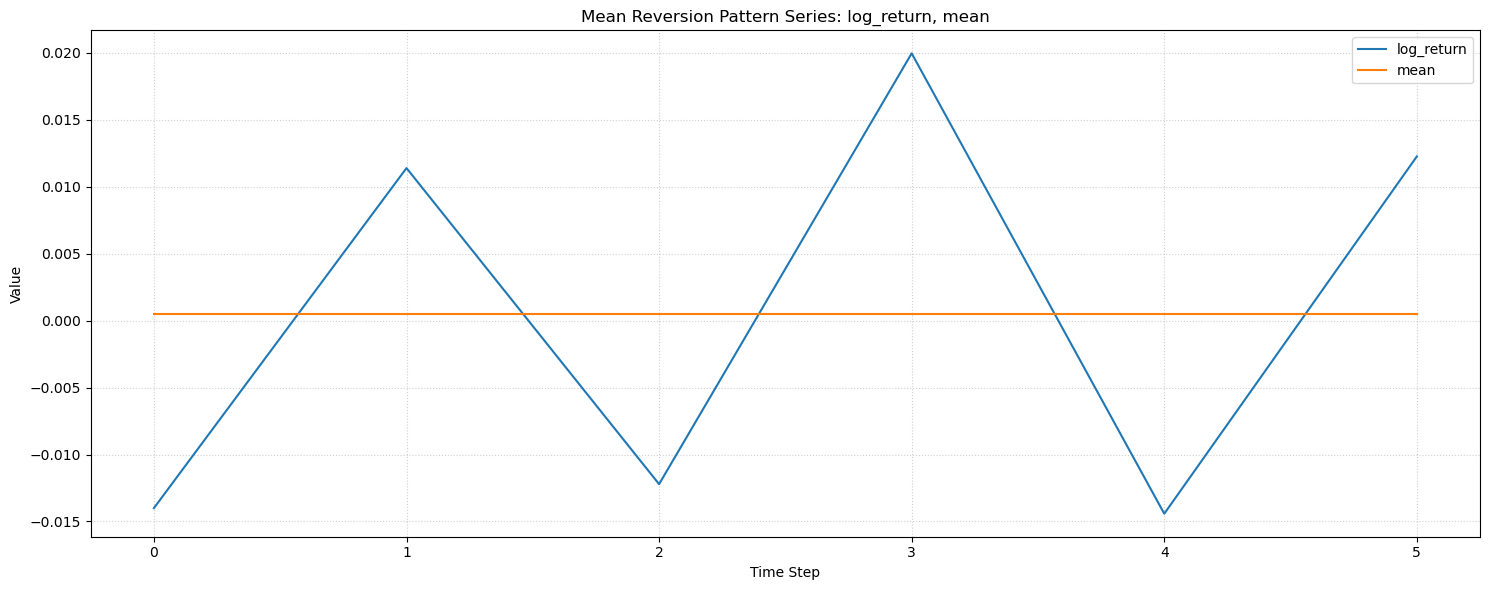

In [11]:

# Visualize mean reversion pattern
series = [-0.014000, 0.011399, -0.012212, 0.01997, -0.01442, 0.01227]
mu = np.mean(series)
mean_reversion_df = pl.DataFrame({'log_return': series, 'mean': mu})
mean_reversion_df

plot_multiple_lines(mean_reversion_df, ['log_return', 'mean'], 'Mean Reversion Pattern')

---
## 4. Model Interpretability

### 4.1 Linear Model (Interpretable)

A linear model with one feature has a clear interpretation:

$$\hat{y} = w \cdot x + b$$

Where:
- $w = -0.099$ (negative = mean reversion)
- $b = 0.0006$ (small positive bias)

In [12]:


def linear_model(x):
    """Simple linear model prediction."""
    w, b = -0.09911217, 0.00059838
    return w * x + b


# Example predictions
print(f"After -1.5% drop: predict {linear_model(-0.015):.4%} (expect reversal up)")
print(f"After +2.0% gain: predict {linear_model(0.02):.4%} (expect reversal down)")
print(f"After ~0% change: predict {linear_model(0.0):.4%} (just the bias)")

After -1.5% drop: predict 0.2085% (expect reversal up)
After +2.0% gain: predict -0.1384% (expect reversal down)
After ~0% change: predict 0.0598% (just the bias)


### 4.2 Non-Linear Model (Less Interpretable)

Neural networks are harder to interpret but can capture complex patterns.

In [13]:


def nn_model(x):
    """Example non-linear model with tanh activation."""
    x = torch.tensor([x])
    W = torch.tensor([0.08035, -0.01478, -0.03523, 0.06777, 0.03789, 0.0013991, -0.13303, 0.8045])
    b = torch.tensor([0.16421])
    return torch.tanh(torch.sum(x * W) + b)


print(f"\nNeural network after -1.5%: {nn_model(-0.015).item():.4f}")
print(f"Neural network after +2.0%: {nn_model(0.02).item():.4f}")

# **Trade-off:** Neural networks may increase expected value but add complexity.
# For trading, we often favor linear models for:
# - Interpretability
# - Robustness to noise
# - Less prone to overfitting


Neural network after -1.5%: 0.1509
Neural network after +2.0%: 0.1785


---
## 5. Strategy Development

### 5.1 Load Time Series Data

In [14]:
sym = 'BTCUSDT'
time_interval = '12h'

# Define date range (same as Part 1)
start_date = datetime(2024, 10, 29, 0, 0)
end_date = datetime(2025, 1, 9, 0, 0)

# Download data if not cached
download_date_range(sym, start_date, end_date)

# Load OHLC time series from cache
ts = load_ohlc_timeseries_range(sym, time_interval, start_date, end_date)
ts

Loading BTCUSDT: 100%|██████████| 73/73 [00:35<00:00,  2.08day/s]


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71440.1
2024-10-29 12:00:00,71440.0,73660.0,70900.0,72739.5
2024-10-30 00:00:00,72739.5,72797.4,71931.1,71995.0
2024-10-30 12:00:00,71994.9,72984.9,71444.2,72349.0
2024-10-31 00:00:00,72349.0,72720.3,72030.5,72213.3
…,…,…,…,…
2025-01-07 12:00:00,100787.0,100914.2,96153.0,96920.3
2025-01-08 00:00:00,96920.2,97242.2,94480.7,95093.9
2025-01-08 12:00:00,95093.8,96064.5,92500.0,95014.1


### 5.2 Add Target and Features

In [15]:

forecast_horizon = 1
ts = add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=3)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71440.1,null,null,null,null
2024-10-29 12:00:00,71440.0,73660.0,70900.0,72739.5,0.018025,null,null,null
2024-10-30 00:00:00,72739.5,72797.4,71931.1,71995.0,-0.010288,0.018025,null,null
2024-10-30 12:00:00,71994.9,72984.9,71444.2,72349.0,0.004905,-0.010288,0.018025,null
2024-10-31 00:00:00,72349.0,72720.3,72030.5,72213.3,-0.001877,0.004905,-0.010288,0.018025
…,…,…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,100914.2,96153.0,96920.3,-0.03912,-0.01373,0.029407,0.0089
2025-01-08 00:00:00,96920.2,97242.2,94480.7,95093.9,-0.019024,-0.03912,-0.01373,0.029407
2025-01-08 12:00:00,95093.8,96064.5,92500.0,95014.1,-0.00084,-0.019024,-0.03912,-0.01373


### 5.3 Time-Based Train/Test Split

We evaluate on the most recent 25% of data.

In [16]:

test_size = 0.25
_, trades = timeseries_split(ts, test_size)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2024-12-22 12:00:00,97054.7,97266.6,94200.0,95153.5,-0.019784,-0.002131,-0.009858,0.004703
2024-12-23 00:00:00,95153.4,96499.0,93655.3,95899.4,0.007808,-0.019784,-0.002131,-0.009858
2024-12-23 12:00:00,95899.4,96377.2,92464.4,94861.1,-0.010886,0.007808,-0.019784,-0.002131
2024-12-24 00:00:00,94861.0,94861.1,93525.6,94369.0,-0.005201,-0.010886,0.007808,-0.019784
2024-12-24 12:00:00,94368.3,99450.0,94039.8,98627.2,0.044134,-0.005201,-0.010886,0.007808
…,…,…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,100914.2,96153.0,96920.3,-0.03912,-0.01373,0.029407,0.0089
2025-01-08 00:00:00,96920.2,97242.2,94480.7,95093.9,-0.019024,-0.03912,-0.01373,0.029407
2025-01-08 12:00:00,95093.8,96064.5,92500.0,95014.1,-0.00084,-0.019024,-0.03912,-0.01373


---
## 6. Strategy Decision #1: Entry/Exit Signal

### Signal Types

1. **Time-Based**: Fixed interval trades (e.g., every 12 hours)
2. **Predicate-Based**: Trade only when prediction exceeds threshold

We use **time-based signals** where each bar represents a roundtrip trade
(open position at bar start, close at bar end = 2 trades per bar).

### 6.1 Add Model Predictions

In [17]:

target = 'close_log_return'
features = [f'{target}_lag_1', f'{target}_lag_2', f'{target}_lag_3']

# Add predictions from our trained model
trades = add_model_predictions(trades, model, features)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32
2024-12-22 12:00:00,97054.7,97266.6,94200.0,95153.5,-0.019784,-0.002131,-0.009858,0.004703,0.001369
2024-12-23 00:00:00,95153.4,96499.0,93655.3,95899.4,0.007808,-0.019784,-0.002131,-0.009858,0.003487
2024-12-23 12:00:00,95899.4,96377.2,92464.4,94861.1,-0.010886,0.007808,-0.019784,-0.002131,0.001051
2024-12-24 00:00:00,94861.0,94861.1,93525.6,94369.0,-0.005201,-0.010886,0.007808,-0.019784,0.002791
2024-12-24 12:00:00,94368.3,99450.0,94039.8,98627.2,0.044134,-0.005201,-0.010886,0.007808,0.001549
…,…,…,…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,100914.2,96153.0,96920.3,-0.03912,-0.01373,0.029407,0.0089,0.001051
2025-01-08 00:00:00,96920.2,97242.2,94480.7,95093.9,-0.019024,-0.03912,-0.01373,0.029407,0.003861
2025-01-08 12:00:00,95093.8,96064.5,92500.0,95014.1,-0.00084,-0.019024,-0.03912,-0.01373,0.004751


### 6.2 Add Directional Signal

Convert continuous predictions to discrete trading signals:

$$\text{signal} = \text{sign}(\hat{y})$$

- $+1$: Go long (buy)
- $-1$: Go short (sell)

In [18]:

trades = trades.with_columns(pl.col('y_hat').sign().alias('dir_signal'))
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32
2024-12-22 12:00:00,97054.7,97266.6,94200.0,95153.5,-0.019784,-0.002131,-0.009858,0.004703,0.001369,1.0
2024-12-23 00:00:00,95153.4,96499.0,93655.3,95899.4,0.007808,-0.019784,-0.002131,-0.009858,0.003487,1.0
2024-12-23 12:00:00,95899.4,96377.2,92464.4,94861.1,-0.010886,0.007808,-0.019784,-0.002131,0.001051,1.0
2024-12-24 00:00:00,94861.0,94861.1,93525.6,94369.0,-0.005201,-0.010886,0.007808,-0.019784,0.002791,1.0
2024-12-24 12:00:00,94368.3,99450.0,94039.8,98627.2,0.044134,-0.005201,-0.010886,0.007808,0.001549,1.0
…,…,…,…,…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,100914.2,96153.0,96920.3,-0.03912,-0.01373,0.029407,0.0089,0.001051,1.0
2025-01-08 00:00:00,96920.2,97242.2,94480.7,95093.9,-0.019024,-0.03912,-0.01373,0.029407,0.003861,1.0
2025-01-08 12:00:00,95093.8,96064.5,92500.0,95014.1,-0.00084,-0.019024,-0.03912,-0.01373,0.004751,1.0


### 6.3 Calculate Trade Log Returns

$$r_{trade} = r_{actual} \times \text{signal}$$

In [19]:

trades = trades.with_columns(
    (pl.col('close_log_return') * pl.col('dir_signal')).alias('trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64
2024-12-22 12:00:00,97054.7,97266.6,94200.0,95153.5,-0.019784,-0.002131,-0.009858,0.004703,0.001369,1.0,-0.019784
2024-12-23 00:00:00,95153.4,96499.0,93655.3,95899.4,0.007808,-0.019784,-0.002131,-0.009858,0.003487,1.0,0.007808
2024-12-23 12:00:00,95899.4,96377.2,92464.4,94861.1,-0.010886,0.007808,-0.019784,-0.002131,0.001051,1.0,-0.010886
2024-12-24 00:00:00,94861.0,94861.1,93525.6,94369.0,-0.005201,-0.010886,0.007808,-0.019784,0.002791,1.0,-0.005201
2024-12-24 12:00:00,94368.3,99450.0,94039.8,98627.2,0.044134,-0.005201,-0.010886,0.007808,0.001549,1.0,0.044134
…,…,…,…,…,…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,100914.2,96153.0,96920.3,-0.03912,-0.01373,0.029407,0.0089,0.001051,1.0,-0.03912
2025-01-08 00:00:00,96920.2,97242.2,94480.7,95093.9,-0.019024,-0.03912,-0.01373,0.029407,0.003861,1.0,-0.019024
2025-01-08 12:00:00,95093.8,96064.5,92500.0,95014.1,-0.00084,-0.019024,-0.03912,-0.01373,0.004751,1.0,-0.00084


### 6.4 Cumulative Returns

In [20]:

trades = trades.with_columns(
    pl.col('trade_log_return').cum_sum().alias('cum_trade_log_return')
)
trades

# Visualize equity curve (log space)
plot_column(trades, 'cum_trade_log_return')

alt.Chart(...)

---
## 7. Strategy Decision #2: Trade Sizing

How much capital should we allocate per trade?

### Two Approaches:

1. **Constant Sizing**: Fixed dollar amount per trade
2. **Compounding Sizing**: Reinvest profits (proportional to equity)

### 7.1 Constant Trade Sizing

Each trade uses a fixed percentage of initial capital.

In [21]:

capital = 100  # Starting capital
ratio = 1.0    # 100% of capital per trade
trade_value = ratio * capital

trades = trades.with_columns(
    # Entry trade value (fixed)
    pl.lit(trade_value).alias('entry_trade_value'),
    # Exit trade value (after P&L)
    (trade_value * pl.col('trade_log_return').exp()).alias('exit_trade_value'),
    # Trade quantity (in base asset)
    (trade_value / pl.col('open')).alias('trade_qty'),
).with_columns(
    # Signed quantity (positive = long, negative = short)
    (pl.col('trade_qty') * pl.col('dir_signal')).alias('signed_trade_qty'),
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat',
              'entry_trade_value', 'exit_trade_value', 'signed_trade_qty')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty
datetime[μs],f64,f64,f64,f32,f64,f64,f64
2024-12-22 12:00:00,97054.7,95153.5,-0.019784,0.001369,100.0,98.041004,0.00103
2024-12-23 00:00:00,95153.4,95899.4,0.007808,0.003487,100.0,100.783891,0.001051
2024-12-23 12:00:00,95899.4,94861.1,-0.010886,0.001051,100.0,98.917303,0.001043
2024-12-24 00:00:00,94861.0,94369.0,-0.005201,0.002791,100.0,99.481242,0.001054
2024-12-24 12:00:00,94368.3,98627.2,0.044134,0.001549,100.0,104.512287,0.00106
…,…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,96920.3,-0.03912,0.001051,100.0,96.163493,0.000992
2025-01-08 00:00:00,96920.2,95093.9,-0.019024,0.003861,100.0,98.115565,0.001032
2025-01-08 12:00:00,95093.8,95014.1,-0.00084,0.004751,100.0,99.916083,0.001052


### 7.2 Calculate Gross P&L

In [22]:

trades = trades.with_columns(
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl')
)

### 7.3 Add Transaction Fees

Fees are charged on both entry and exit:

$$\text{Fee}_{roundtrip} = \text{Fee}_{entry} + \text{Fee}_{exit}$$

In [23]:

taker_fee = TAKER_FEE  # 0.045%
maker_fee = MAKER_FEE  # 0.045%

trades = trades.with_columns(
    (pl.col('entry_trade_value') * taker_fee + pl.col('exit_trade_value') * taker_fee).alias('taker_fee'),
    (pl.col('entry_trade_value') * maker_fee + pl.col('exit_trade_value') * maker_fee).alias('maker_fee')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat',
              'entry_trade_value', 'exit_trade_value', 'signed_trade_qty',
              'trade_gross_pnl', 'maker_fee', 'taker_fee')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,maker_fee,taker_fee
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2024-12-22 12:00:00,97054.7,95153.5,-0.019784,0.001369,100.0,98.041004,0.00103,-1.958996,0.089118,0.089118
2024-12-23 00:00:00,95153.4,95899.4,0.007808,0.003487,100.0,100.783891,0.001051,0.783891,0.090353,0.090353
2024-12-23 12:00:00,95899.4,94861.1,-0.010886,0.001051,100.0,98.917303,0.001043,-1.082697,0.089513,0.089513
2024-12-24 00:00:00,94861.0,94369.0,-0.005201,0.002791,100.0,99.481242,0.001054,-0.518758,0.089767,0.089767
2024-12-24 12:00:00,94368.3,98627.2,0.044134,0.001549,100.0,104.512287,0.00106,4.512287,0.092031,0.092031
…,…,…,…,…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,96920.3,-0.03912,0.001051,100.0,96.163493,0.000992,-3.836507,0.088274,0.088274
2025-01-08 00:00:00,96920.2,95093.9,-0.019024,0.003861,100.0,98.115565,0.001032,-1.884435,0.089152,0.089152
2025-01-08 12:00:00,95093.8,95014.1,-0.00084,0.004751,100.0,99.916083,0.001052,-0.083917,0.089962,0.089962


### 7.4 Calculate Net P&L

$$\text{Net P\&L} = \text{Gross P\&L} - \text{Fees}$$

In [24]:

trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('taker_fee')).alias('trade_net_taker_pnl'),
    (pl.col('trade_gross_pnl') - pl.col('maker_fee')).alias('trade_net_maker_pnl'),
)

trades.select('datetime', 'trade_gross_pnl', 'trade_net_taker_pnl', 'trade_net_maker_pnl')

datetime,trade_gross_pnl,trade_net_taker_pnl,trade_net_maker_pnl
datetime[μs],f64,f64,f64
2024-12-22 12:00:00,-1.958996,-2.048115,-2.048115
2024-12-23 00:00:00,0.783891,0.693539,0.693539
2024-12-23 12:00:00,-1.082697,-1.17221,-1.17221
2024-12-24 00:00:00,-0.518758,-0.608525,-0.608525
2024-12-24 12:00:00,4.512287,4.420256,4.420256
…,…,…,…
2025-01-07 12:00:00,-3.836507,-3.92478,-3.92478
2025-01-08 00:00:00,-1.884435,-1.973587,-1.973587
2025-01-08 12:00:00,-0.083917,-0.173879,-0.173879


### 7.5 Equity Curves (Constant Sizing)

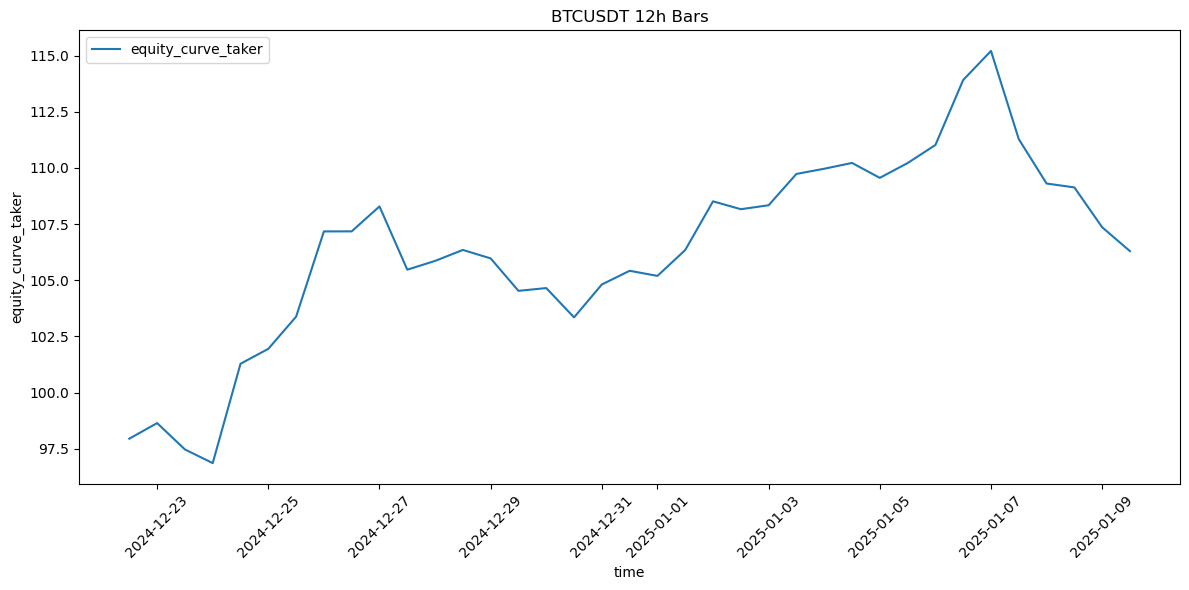

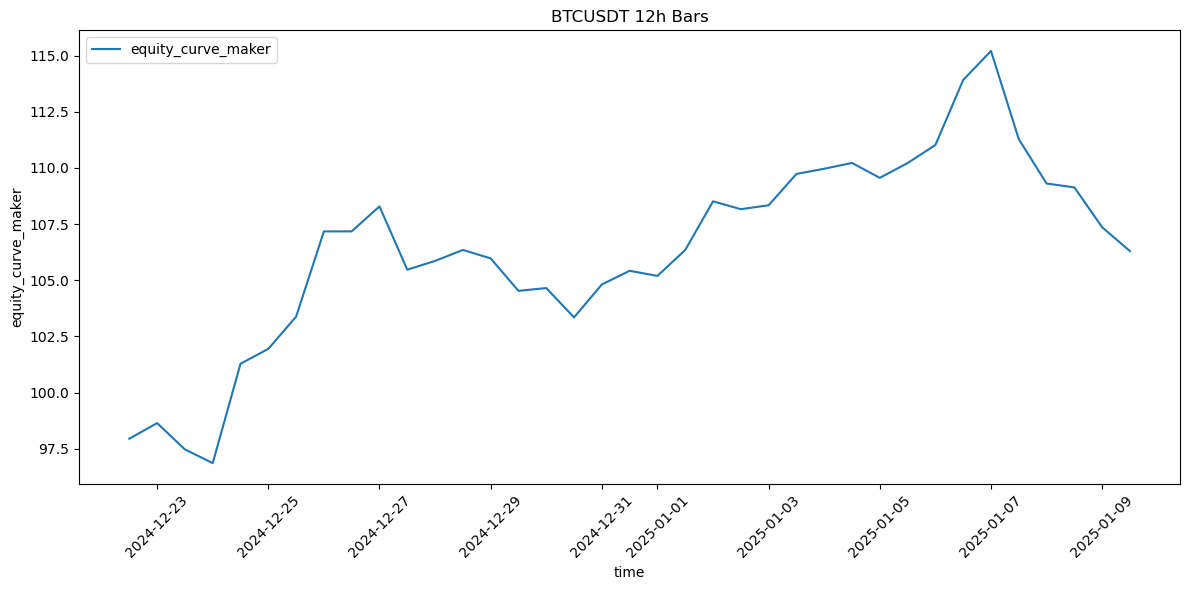

Constant Sizing Net Return: 6.30%


In [25]:


def equity_curve(capital, col_name, suffix):
    """Calculate cumulative equity curve."""
    return (capital + (pl.col(col_name).cum_sum())).alias(f'equity_curve_{suffix}')


trades = trades.with_columns(
    equity_curve(capital, 'trade_net_taker_pnl', 'taker'),
    equity_curve(capital, 'trade_net_maker_pnl', 'maker'),
    equity_curve(capital, 'trade_gross_pnl', 'gross'),
)

trades.select('datetime', 'equity_curve_gross', 'equity_curve_taker', 'equity_curve_maker')

# Visualize equity curves
plot_static_timeseries(trades, sym, 'equity_curve_taker', time_interval)
plot_static_timeseries(trades, sym, 'equity_curve_maker', time_interval)

# Total return with constant sizing
constant_sizing_net_return = trades['equity_curve_taker'][-1] / capital - 1
print(f"Constant Sizing Net Return: {constant_sizing_net_return:.2%}")

---
## 8. Compounding Trade Sizing

### The Power of Compounding

With compounding, each trade uses our current equity (including profits).

**Time Additivity of Log Returns:**

$$\text{Final Equity} = \text{Capital} \times e^{\sum r_t}$$

This is why we use log returns - they add up over time!

In [26]:

# Example: Three consecutive returns
log_return_1 = 0.005439
log_return_2 = 0.008597
log_return_3 = 0.001385

# Step by step compounding
pnl1 = capital * np.exp(log_return_1)
pnl2 = pnl1 * np.exp(log_return_2)
pnl3 = pnl2 * np.exp(log_return_3)

print(f"After trade 1: ${pnl1:.2f}")
print(f"After trade 2: ${pnl2:.2f}")
print(f"After trade 3: ${pnl3:.2f}")

# Equivalent using time additivity
final = capital * np.exp(log_return_1 + log_return_2 + log_return_3)
print(f"\nUsing time additivity: ${final:.2f}")

After trade 1: $100.55
After trade 2: $101.41
After trade 3: $101.55

Using time additivity: $101.55


### 8.1 Implement Compounding

In [27]:

trades = trades.with_columns(
    # Entry value = previous cumulative equity
    ((pl.col('cum_trade_log_return').exp()) * capital).shift().fill_null(capital).alias('entry_trade_value'),
    # Exit value = current cumulative equity
    ((pl.col('cum_trade_log_return').exp()) * capital).alias('exit_trade_value'),
).with_columns(
    (pl.col('entry_trade_value') / pl.col('open') * pl.col('dir_signal')).alias('signed_trade_qty'),
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl'),
)

trades.select('datetime', 'open', 'close', 'trade_log_return',
              'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

# Add fees using library function
trades = add_tx_fees(trades, MAKER_FEE, TAKER_FEE)
trades.select('datetime', 'entry_trade_value', 'exit_trade_value', 'tx_fee_maker', 'tx_fee_taker')

# Calculate net P&L
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('tx_fee_taker')).alias('trade_net_taker_pnl')
)

trades.select('datetime', 'open', 'close', 'close_log_return', 'y_hat',
              'entry_trade_value', 'exit_trade_value', 'trade_gross_pnl', 'trade_net_taker_pnl')

datetime,open,close,close_log_return,y_hat,entry_trade_value,exit_trade_value,trade_gross_pnl,trade_net_taker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2024-12-22 12:00:00,97054.7,95153.5,-0.019784,0.001369,100.0,98.041004,-1.958996,-2.048115
2024-12-23 00:00:00,95153.4,95899.4,0.007808,0.003487,98.041004,98.809539,0.768535,0.679952
2024-12-23 12:00:00,95899.4,94861.1,-0.010886,0.001051,98.809539,97.739731,-1.069808,-1.158255
2024-12-24 00:00:00,94861.0,94369.0,-0.005201,0.002791,97.739731,97.232697,-0.507033,-0.594771
2024-12-24 12:00:00,94368.3,98627.2,0.044134,0.001549,97.232697,101.620116,4.387418,4.297934
…,…,…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,96920.3,-0.03912,0.001051,119.34952,114.770667,-4.578852,-4.684206
2025-01-08 00:00:00,96920.2,95093.9,-0.019024,0.003861,114.770667,112.607889,-2.162779,-2.265099
2025-01-08 12:00:00,95093.8,95014.1,-0.00084,0.004751,112.607889,112.513391,-0.094497,-0.195802


### 8.2 Equity Curve (Compounding)

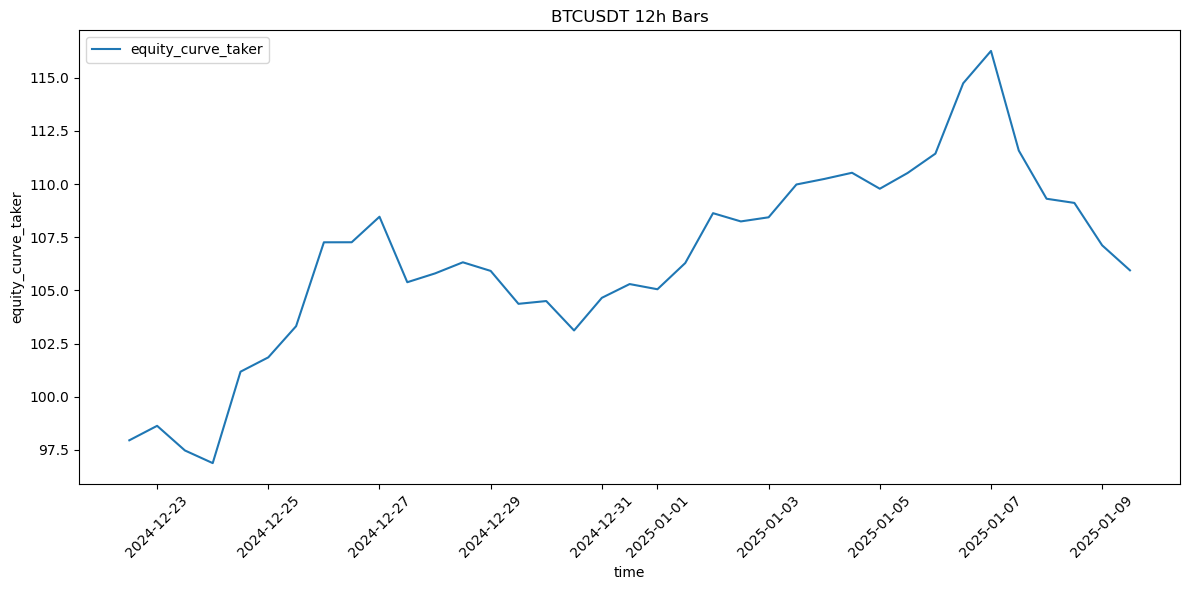


Compounding Net Return: 5.94%
Constant Sizing Net Return: 6.30%
Improvement: -0%


In [28]:

trades = add_equity_curve(trades, capital, 'trade_net_taker_pnl', 'taker')
plot_static_timeseries(trades, sym, 'equity_curve_taker', time_interval)

# Compare constant vs compounding
compound_total_net_return = trades['equity_curve_taker'][-1] / capital - 1
print(f"\nCompounding Net Return: {compound_total_net_return:.2%}")
print(f"Constant Sizing Net Return: {constant_sizing_net_return:.2%}")
print(f"Improvement: {np.round(compound_total_net_return - constant_sizing_net_return, 2):.0%}")

---
## 9. Strategy Decision #3: Leverage

### Understanding Leverage

Leverage means borrowing money to increase position size.

$$\text{Effective Capital} = \text{Capital} \times \text{Leverage}$$

**Example:** With 4x leverage and $100, you can trade as if you had $400.

In [29]:

leverage = 4
print(f"Capital: ${capital}")
print(f"Effective capital with {leverage}x leverage: ${leverage * capital}")

Capital: $100
Effective capital with 4x leverage: $400


### Important Considerations

- Leverage **amplifies both profits AND losses**
- Only effective with high Sharpe ratio models
- Too much leverage can lead to **liquidation** (total loss)

### 9.1 Add Leverage to Strategy

In [30]:

# Using library function for compounding trades with leverage
trades = add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

leveraged_return_4x = trades['equity_curve_taker'][-1] / capital - 1
print(f"\n4x Leverage Net Return: {leveraged_return_4x:.2%}")


4x Leverage Net Return: 23.77%


### 9.2 Experiment with Higher Leverage

In [31]:

trades = add_compounding_trades(trades, capital, 8, maker_fee, taker_fee)

leveraged_return_8x = trades['equity_curve_taker'][-1] / capital - 1
print(f"8x Leverage Net Return: {leveraged_return_8x:.2%}")

# **Why such high returns?**
# Combination of:
# 1. Model's statistical edge
# 2. Compounding effect
# 3. Leverage amplification
#
# **Warning:** This only works at small scale where we don't move markets.

8x Leverage Net Return: 47.54%


### 9.3 Win Rate Consistency

Verify that win rate hasn't changed (not manipulating results).

In [32]:

win_rate = trades.select((pl.col("trade_log_return") > 0).mean())
print(f"\nWin Rate: {win_rate.item():.2%}")


Win Rate: 59.46%


---
## 10. Risk Management: Liquidation

### Understanding Liquidation

Liquidation occurs when your losses exceed your margin (collateral).
The exchange closes your position to prevent further losses.

### Liquidation Price Formulas

For **long positions** (buying):

$$P_{liq} = \frac{P_{entry} \times L}{L + 1 - MMR \times L}$$

For **short positions** (selling):

$$P_{liq} = \frac{P_{entry} \times L}{L - 1 + MMR \times L}$$

Where:
- $P_{entry}$ = Entry price
- $L$ = Leverage
- $MMR$ = Maintenance Margin Rate (typically 0.5%)

In [33]:

maintenance_margin = 0.005  # 0.5%


def long_liquidation_price(p, l, mmr):
    """Calculate liquidation price for long positions."""
    return (p * l) / (l + 1 - mmr * l)


def short_liquidation_price(p, l, mmr):
    """Calculate liquidation price for short positions."""
    return (p * l) / (l - 1 + mmr * l)

### 10.1 How Leverage Affects Long Positions

In [34]:

entry_price = 200
print(f"Entry Price: ${entry_price}")
print(f"\nLong Position Liquidation Prices:")
print(f"  2x leverage: ${long_liquidation_price(entry_price, 2, maintenance_margin):.2f} (need 50% drop)")
print(f"  4x leverage: ${long_liquidation_price(entry_price, 4, maintenance_margin):.2f} (need 25% drop)")
print(f" 10x leverage: ${long_liquidation_price(entry_price, 10, maintenance_margin):.2f} (need 10% drop)")
print(f" 50x leverage: ${long_liquidation_price(entry_price, 50, maintenance_margin):.2f} (need 2% drop)")

Entry Price: $200

Long Position Liquidation Prices:
  2x leverage: $133.78 (need 50% drop)
  4x leverage: $160.64 (need 25% drop)
 10x leverage: $182.65 (need 10% drop)
 50x leverage: $197.04 (need 2% drop)


### 10.2 How Leverage Affects Short Positions

In [35]:

print(f"\nShort Position Liquidation Prices:")
print(f"  2x leverage: ${short_liquidation_price(entry_price, 2, maintenance_margin):.2f} (need 50% rise)")
print(f"  4x leverage: ${short_liquidation_price(entry_price, 4, maintenance_margin):.2f} (need 25% rise)")
print(f" 10x leverage: ${short_liquidation_price(entry_price, 10, maintenance_margin):.2f} (need 10% rise)")
print(f" 60x leverage: ${short_liquidation_price(entry_price, 60, maintenance_margin):.2f} (need 1.7% rise)")


Short Position Liquidation Prices:
  2x leverage: $396.04 (need 50% rise)
  4x leverage: $264.90 (need 25% rise)
 10x leverage: $220.99 (need 10% rise)
 60x leverage: $202.36 (need 1.7% rise)


### 10.3 Add Liquidation Prices to Trades

In [36]:

trades = trades.with_columns(
    pl.when(pl.col("dir_signal") == 1)  # Long position
      .then(
          (pl.col("open") * leverage)
          / (leverage + 1 - maintenance_margin * leverage)
      )
      .when(pl.col("dir_signal") == -1)  # Short position
      .then(
          (pl.col("open") * leverage)
          / (leverage - 1 + maintenance_margin * leverage)
      )
      .otherwise(None)
      .alias("liquidation_price")
)

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal')

datetime,open,high,low,close,liquidation_price,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f32
2024-12-22 12:00:00,97054.7,97266.6,94200.0,95153.5,77955.582329,1.0
2024-12-23 00:00:00,95153.4,96499.0,93655.3,95899.4,76428.433735,1.0
2024-12-23 12:00:00,95899.4,96377.2,92464.4,94861.1,77027.630522,1.0
2024-12-24 00:00:00,94861.0,94861.1,93525.6,94369.0,76193.574297,1.0
2024-12-24 12:00:00,94368.3,99450.0,94039.8,98627.2,75797.831325,1.0
…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,100914.2,96153.0,96920.3,80953.413655,1.0
2025-01-08 00:00:00,96920.2,97242.2,94480.7,95093.9,77847.550201,1.0
2025-01-08 12:00:00,95093.8,96064.5,92500.0,95014.1,76380.562249,1.0


### 10.4 Add Liquidation Flag

Check if price touched liquidation level during the bar.

In [37]:

trades = trades.with_columns([
    # Worst price for our position (low for longs, high for shorts)
    pl.when(pl.col("dir_signal") == 1)
      .then(pl.col("low"))
      .otherwise(pl.col("high"))
      .alias("worst_price"),

    # Liquidation flag
    pl.when(
        (pl.col("dir_signal") == 1) & (pl.col("low") <= pl.col("liquidation_price"))
    )
    .then(True)
    .when(
        (pl.col("dir_signal") == -1) & (pl.col("high") >= pl.col("liquidation_price"))
    )
    .then(True)
    .otherwise(False)
    .alias("liquidated")
])

trades.select('datetime', 'open', 'low', 'high', 'close', 'dir_signal',
              'worst_price', 'liquidation_price', 'liquidated')

datetime,open,low,high,close,dir_signal,worst_price,liquidation_price,liquidated
datetime[μs],f64,f64,f64,f64,f32,f64,f64,bool
2024-12-22 12:00:00,97054.7,94200.0,97266.6,95153.5,1.0,94200.0,77955.582329,false
2024-12-23 00:00:00,95153.4,93655.3,96499.0,95899.4,1.0,93655.3,76428.433735,false
2024-12-23 12:00:00,95899.4,92464.4,96377.2,94861.1,1.0,92464.4,77027.630522,false
2024-12-24 00:00:00,94861.0,93525.6,94861.1,94369.0,1.0,93525.6,76193.574297,false
2024-12-24 12:00:00,94368.3,94039.8,99450.0,98627.2,1.0,94039.8,75797.831325,false
…,…,…,…,…,…,…,…,…
2025-01-07 12:00:00,100787.0,96153.0,100914.2,96920.3,1.0,96153.0,80953.413655,false
2025-01-08 00:00:00,96920.2,94480.7,97242.2,95093.9,1.0,94480.7,77847.550201,false
2025-01-08 12:00:00,95093.8,92500.0,96064.5,95014.1,1.0,92500.0,76380.562249,false


### 10.5 Check for Liquidated Trades

In [38]:

liquidated_trades = trades.filter(pl.col("liquidated") == True)
print(f"\nNumber of liquidated trades: {len(liquidated_trades)}")
if len(liquidated_trades) > 0:
    print("WARNING: Some trades would have been liquidated!")
    print(liquidated_trades)


Number of liquidated trades: 0


---
## Summary

In this notebook, we covered the three key strategy decisions:

### 1. Entry/Exit (Signal Generation)
- Time-based signals (every 12 hours)
- Direction from model predictions: $\text{signal} = \text{sign}(\hat{y})$

### 2. Trade Sizing
- **Constant sizing**: Fixed amount per trade
- **Compounding**: Reinvest profits for exponential growth
- Compounding significantly improves returns

### 3. Leverage
- Multiplies both profits and losses
- Requires high Sharpe ratio model
- Must account for liquidation risk

### Topics for Further Study
- **Alpha decay**: Model performance degradation over time
- **Market impact**: Large trades moving prices against us
- **Funding fees**: Periodic payments in perpetual futures
- **Slippage**: Not getting the exact expected price

**Next:** In Part 3, we'll implement this strategy in real-time
with a proper trading system architecture.